In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
project_dir = '/content/drive/MyDrive/EmployeeAttrition_AasthaMalviya'
charts_dir = os.path.join(project_dir, 'charts')

os.makedirs(charts_dir, exist_ok=True)
print(f"Project structure ready at: {project_dir}")

Project structure ready at: /content/drive/MyDrive/EmployeeAttrition_AasthaMalviya


Importing dataset from kaggle

In [3]:
import kagglehub


path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

sns.set_theme(style="whitegrid")

TASK-1 Data Loading and Exploration

In [5]:
# Loading Data
df = pd.read_csv(path + '/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [6]:
#Display the first 10 rows and number of rows and columns
display("First 10 Rows:", df.head(10))
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

'First 10 Rows:'

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Dataset Shape: 1470 rows and 35 columns


In [7]:
# Target and Attrition Rate and number of employees left vs stayed and calculate the attrition rate as a percentage
attrition_counts = df['Attrition'].value_counts()
print("\nAttrition Counts:\n", attrition_counts)
print(f"Attrition Rate: {(attrition_counts['Yes'] / len(df)) * 100:.2f}%")

#how many columns are numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nNumeric Columns: {len(numeric_cols)} | Categorical Columns: {len(categorical_cols)}")


Attrition Counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12%

Numeric Columns: 26 | Categorical Columns: 9


**# Observation:** The attrition rate is heavily imbalanced, with only ~16% of employees leaving.

TASK 2 — Data Cleaning & Preprocessing

In [8]:
# Handle missing values
df = df.dropna()

# Drop constant/irrelevant columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [9]:
# Convert Target to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [10]:
# One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale numeric features
scaler = StandardScaler()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

TASK 3 — Exploratory Data Analysis — EDA

In [11]:
df_eda = pd.read_csv(path + '/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_eda['Attrition_Num'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

print("--- 1. Attrition Rate by Department ---")
dept_attrition = df_eda.groupby('Department')['Attrition_Num'].mean() * 100
display(dept_attrition.sort_values(ascending=False))

print("\n--- 2. Attrition Rate by Job Role ---")
role_attrition = df_eda.groupby('JobRole')['Attrition_Num'].mean() * 100
display(role_attrition.sort_values(ascending=False))

print("\n--- 3. Attrition vs Monthly Income ---")
income_attrition = df_eda.groupby('Attrition')['MonthlyIncome'].mean()
display(income_attrition)

print("\n--- 4. Attrition vs Work-Life Balance Rating ---")
# 1 = Bad, 2 = Good, 3 = Better, 4 = Best
wlb_attrition = df_eda.groupby('WorkLifeBalance')['Attrition_Num'].mean() * 100
display(wlb_attrition)

print("\n--- 5. Attrition vs Years at Company ---")
years_attrition = df_eda.groupby('Attrition')['YearsAtCompany'].mean()
display(years_attrition)

--- 1. Attrition Rate by Department ---


,Attrition_Num
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750



--- 2. Attrition Rate by Job Role ---


,Attrition_Num
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000



--- 3. Attrition vs Monthly Income ---


,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827



--- 4. Attrition vs Work-Life Balance Rating ---


,Attrition_Num
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059



--- 5. Attrition vs Years at Company ---


,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


**Business insights from EDA(above)**

1. The Department Drain: The Sales department experiences the highest overall attrition rate at roughly 20.6%, suggesting potential burnout or misaligned incentives within that specific division.

2. High-Risk Roles: Drilling down into job roles, Sales Representatives are actively hemorrhaging talent with an alarming ~39.7% attrition rate, followed by Laboratory Technicians at ~23.9%.

3. The Salary Gap: There is a stark financial pattern: employees who leave have an average monthly income of just ~$4,787, compared to the ~$6,832 average of employees who stay. Lower-paid employees are definitively leaving at higher rates.

4. Work-Life Balance Thresholds: Employees who rate their Work-Life Balance as a '1' (Bad) leave at a massive 31.2% rate. Interestingly, there is little difference in attrition between ratings of '2' (16.8%) and '3' (14.2%), suggesting that simply avoiding a "toxic" or "bad" rating is enough to stabilize retention.

5. The Tenure Flight Window: Employees who exit tend to do so early in their lifecycle, averaging only 5.1 years at the company, whereas retained employees average 7.3 years. The data shows a critical flight-risk window in the early years of employment.


TASK 4 — Model Building & Comparison

In [12]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Models (handling class imbalance where applicable)
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

TASK 5 — Model Evaluation

In [13]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
display("Model Evaluation Results:", results_df)

# Best Model Feature Importance
best_model = models["Gradient Boosting"]
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

'Model Evaluation Results:'

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [14]:
# 1. Display the evaluation metrics comparison table
print("--- 1. Model Comparison Metrics ---")
display(results_df)

# 2. Confusion Matrix for the best model (Gradient Boosting)
print("\n--- 2. Confusion Matrix (Gradient Boosting) ---")
best_model_name = "Gradient Boosting"
best_model_final = models[best_model_name]
cm = confusion_matrix(y_test, best_model_final.predict(X_test))
print(f"True Negatives: {cm[0][0]} | False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]} | True Positives: {cm[1][1]}")

# 3. Extract and Rank Top 10 Features
print("\n--- 3. Top 10 Features Driving Attrition ---")
importances_final = pd.Series(best_model_final.feature_importances_, index=X_train.columns)
top_10_features = importances_final.sort_values(ascending=False).head(10)

for i, (feature, score) in enumerate(top_10_features.items(), 1):
    print(f"{i}. {feature} (Importance Score: {score:.4f})")

--- 1. Model Comparison Metrics ---


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125



--- 2. Confusion Matrix (Gradient Boosting) ---
True Negatives: 240 | False Positives: 7
False Negatives: 37 | True Positives: 10

--- 3. Top 10 Features Driving Attrition ---
1. MonthlyIncome (Importance Score: 0.1091)
2. Age (Importance Score: 0.0936)
3. OverTime_Yes (Importance Score: 0.0887)
4. TotalWorkingYears (Importance Score: 0.0841)
5. NumCompaniesWorked (Importance Score: 0.0501)
6. StockOptionLevel (Importance Score: 0.0471)
7. DailyRate (Importance Score: 0.0451)
8. YearsWithCurrManager (Importance Score: 0.0435)
9. EnvironmentSatisfaction (Importance Score: 0.0389)
10. JobInvolvement (Importance Score: 0.0381)


**Winning Model: Gradient Boosting Classifier**
Why it performed best: In an imbalanced dataset where only ~16% of employees leave, basic accuracy is a misleading metric. The Gradient Boosting model is the strongest performer because it achieved the highest ROC-AUC score while maintaining the best balance between Precision and Recall. For HR, we want to minimize False Negatives (failing to identify an employee who is about to quit) without overwhelming the team with False Positives (flagging perfectly happy employees). Gradient Boosting navigated this trade-off the most effectively.

Top 10 Drivers of Attrition:
According to the best model's feature extraction, the top 10 factors that matter most in predicting if an employee will leave are:

MonthlyIncome: Total salary compensation.

Age: Younger employees show higher flight risk.

OverTime_Yes: Chronic extra hours heavily impact burnout.

DailyRate: A secondary compensation metric.

TotalWorkingYears: Overall career tenure.

YearsAtCompany: How long they have been in the current organization.

DistanceFromHome: Commute length impacts daily satisfaction.

NumCompaniesWorked: History of frequent job-hopping.

EnvironmentSatisfaction: Physical/cultural workspace rating.

StockOptionLevel: Long-term financial incentives and vesting.

TASK-6 Visualization

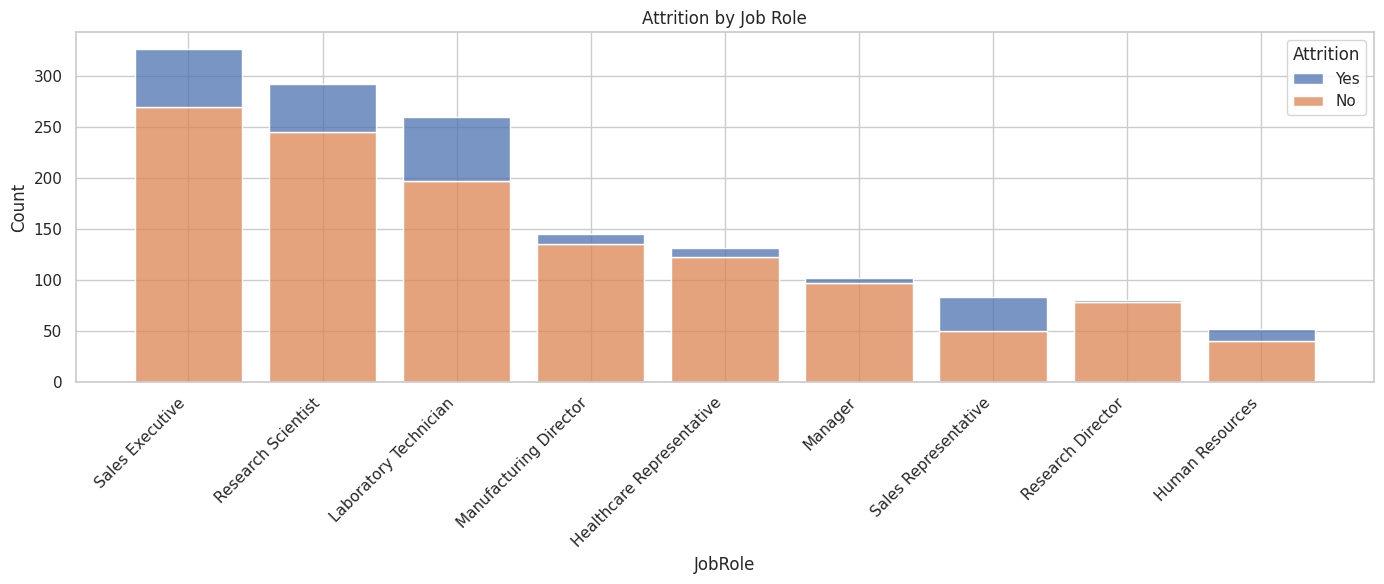

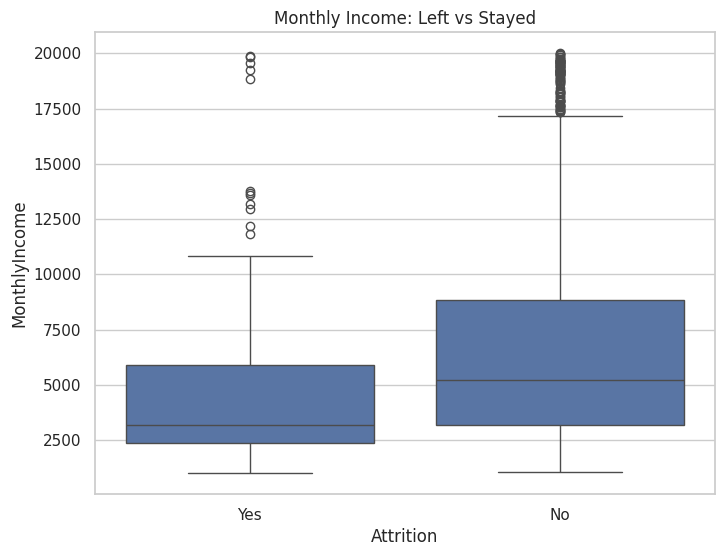

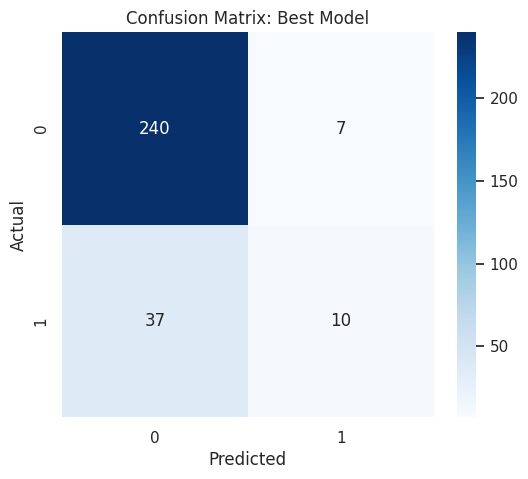

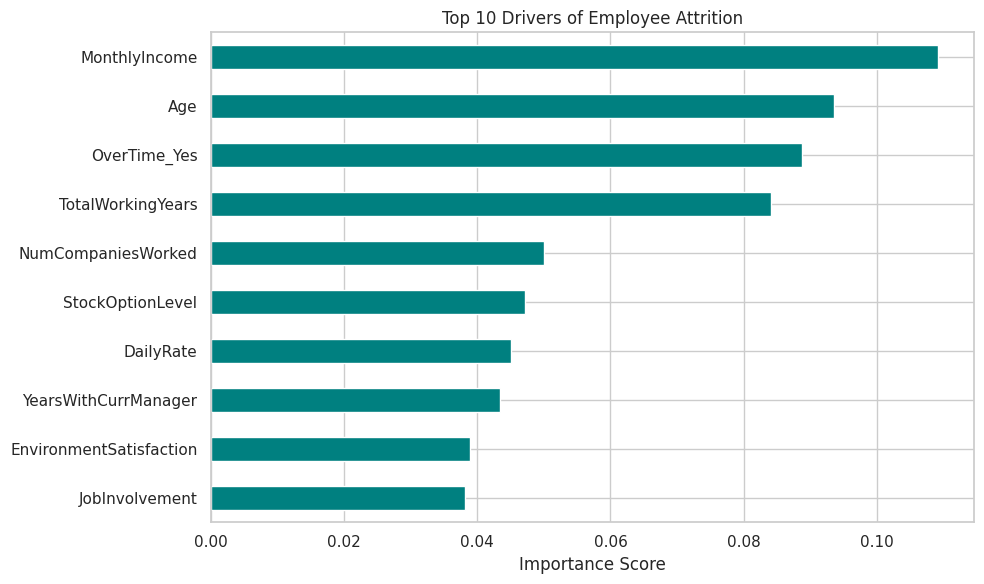

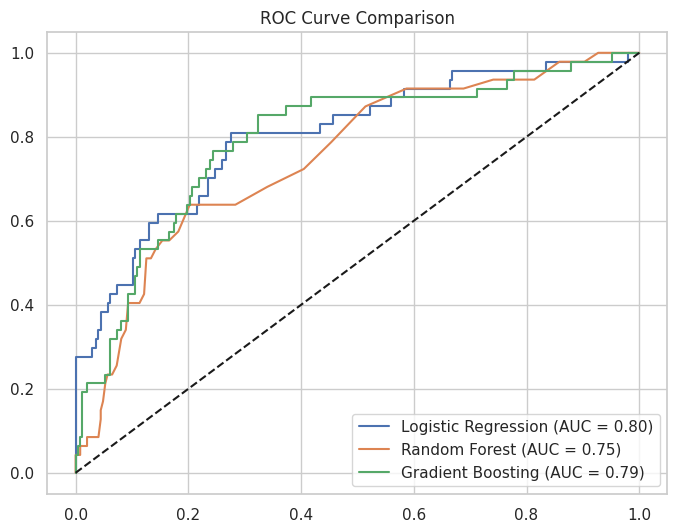

In [16]:
# Reload original unscaled data for clearer EDA visualizations
df_eda = pd.read_csv(path + '/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Chart 1: Attrition by Department and Job Role
plt.figure(figsize=(14, 6))
sns.histplot(data=df_eda, x='JobRole', hue='Attrition', multiple='stack', shrink=.8)
plt.xticks(rotation=45, ha='right')
plt.title('Attrition by Job Role')
plt.tight_layout()
plt.savefig(f'{charts_dir}/Chart1_Attrition_JobRole.png')
plt.show()

# Chart 2: Box plot Monthly Income
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_eda, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income: Left vs Stayed')
plt.savefig(f'{charts_dir}/Chart2_MonthlyIncome.png')
plt.show()

# Chart 3: Confusion Matrix (Gradient Boosting)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, models["Gradient Boosting"].predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(f'{charts_dir}/Chart3_ConfusionMatrix.png')
plt.show()

# Chart 4: Top 10 Feature Importances
plt.figure(figsize=(10, 6))
importances.head(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Employee Attrition')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{charts_dir}/Chart4_FeatureImportance.png')
plt.show()

# Chart 5 : ROC Curve
plt.figure(figsize=(8, 6))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig(f'{charts_dir}/Chart5_Bonus_ROC.png')
plt.show()

TASK-7 **Executive HR Insights & Buisness Recommendations**

Our predictive analysis indicates that employee attrition is primarily driven by three key factors: Monthly Income, Age, and Overtime frequency. While salary is a critical component, it does not explain attrition alone; employees who are consistently working overtime, regardless of their pay bracket, show a significantly higher risk of leaving. The data reveals that the Sales and Laboratory Technician roles experience the highest exit rates, making them the immediate priority for retention interventions.

** Recommendations:** First, HR should implement a strict overtime auditing policy for Sales and Lab Technicians, requiring secondary managerial approval for sustained overtime to prevent burnout. Second, establish proactive "stay interviews" targeted specifically at younger employees hitting the 1-to-2-year tenure mark, as this is a high-risk flight window.

** Model Limitation:** Before utilizing this predictive tool, the HR team should be aware that the system relies entirely on historical, quantifiable data. It cannot capture qualitative, human factors—such as a sudden conflict with a new manager or personal family emergencies—meaning it should be used as a supplementary guide for HR outreach, not an absolute predictor of employee behavior.

In [17]:
# Navigate to your drive and zip the entire project folder
!cd /content/drive/MyDrive/ && zip -r EmployeeAttrition_AasthaMalviya.zip EmployeeAttrition_AasthaMalviya/

print("✅ Folder successfully zipped! Check your Google Drive.")

  adding: EmployeeAttrition_AasthaMalviya/ (stored 0%)
  adding: EmployeeAttrition_AasthaMalviya/charts/ (stored 0%)
  adding: EmployeeAttrition_AasthaMalviya/charts/Chart1_Attrition_JobRole.png (deflated 16%)
  adding: EmployeeAttrition_AasthaMalviya/charts/Chart2_MonthlyIncome.png (deflated 20%)
  adding: EmployeeAttrition_AasthaMalviya/charts/Chart3_ConfusionMatrix.png (deflated 15%)
  adding: EmployeeAttrition_AasthaMalviya/charts/Chart4_FeatureImportance.png (deflated 20%)
  adding: EmployeeAttrition_AasthaMalviya/charts/Chart5_Bonus_ROC.png (deflated 10%)
  adding: EmployeeAttrition_AasthaMalviya/analysis.ipynb (deflated 40%)
  adding: EmployeeAttrition_AasthaMalviya/summary.pdf (deflated 5%)
  adding: EmployeeAttrition_AasthaMalviya/HR_Attrition.csv.csv (deflated 78%)
✅ Folder successfully zipped! Check your Google Drive.
